Este notebook une los 5 datasets normalizados (elecciones, delitos de odio,
desigualdad, desempleo, inmigración) en una única tabla con granularidad
**comunidad autónoma + año**, lista para análisis exploratorio y modelos.

In [1]:
import pandas as pd

Carga de los 5 datasets procesados

Se comprueba el número de filas y columnas de cada dataset.

Esta revisión sirve para verificar que los archivos se han cargado correctamente y que cada tabla tiene una estructura coherente antes de hacer transformaciones o merges.

In [2]:
RUTA = r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"

elecciones = pd.read_csv(
    RUTA + r"\01_data\02_processed\elecciones\elecciones_total.csv"
)

delitos = pd.read_csv(
    RUTA + r"\01_data\02_processed\delito_de_odio\delitos_odio_ccaa.csv"
)

desigualdad = pd.read_csv(
    RUTA + r"\01_data\02_processed\indicadores_sociales\desigualdad\desigualdad_españa.csv"
)

desempleo = pd.read_csv(
    RUTA + r"\01_data\02_processed\indicadores_sociales\desempleo\desempleo_españa.csv"
)

inmigracion = pd.read_csv(
    RUTA + r"\01_data\02_processed\indicadores_sociales\inmigracion\inmigracion_españa.csv"
)

poblacion = pd.read_csv(
    RUTA + r"\01_data\02_processed\indicadores_sociales\poblacion\poblacion.csv"
)

print("Elecciones:", elecciones.shape)
print("Delitos:", delitos.shape)
print("Desigualdad:", desigualdad.shape)
print("Desempleo:", desempleo.shape)
print("Inmigración:", inmigracion.shape)
print("Población:", poblacion.shape)

Elecciones: (1216, 8)
Delitos: (2717, 4)
Desigualdad: (684, 4)
Desempleo: (209, 3)
Inmigración: (209, 3)
Población: (228, 3)


In [3]:
poblacion = poblacion[
    poblacion['año'] <= 2024
]

poblacion.shape

(209, 3)

El dataset de elecciones tiene 237 siglas distintas debido a coaliciones
y variantes territoriales del mismo partido. Para poder analizar la
relación entre voto e ideología, agrupamos los partidos en bloques
(Izquierda, Centro, Derecha, Extrema derecha).

Primero calculamos el ranking de partidos por volumen de votos, para
priorizar la clasificación de los que tienen peso real.

In [4]:
ranking_partidos = (
    elecciones
    .groupby('siglas')['votos']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

ranking_partidos.head(50)

,siglas,votos
0,PP,31429039
1,PSOE,25025748
2,VOX,9507367
3,C's,6656098
4,Cs,5805983
5,PODEMOS,3198584
6,PSC,2773866
7,PODEMOS-IU-,2732814
8,PSdeG-PSOE,2178287
9,SUMAR,1973254


Como muchos partidos tienen poca cantidad de votos miramos el porcentaje que representa cada partido y además, el porcentaje acumulado, de esta manera podremos decidir qué partidos merece la pena clasificar.

In [5]:
ranking_partidos['porcentaje'] = (
    ranking_partidos['votos']
    / ranking_partidos['votos'].sum()
    * 100
)

ranking_partidos['porcentaje_acumulado'] = (
    ranking_partidos['porcentaje'].cumsum()
)

ranking_partidos.head(50)

,siglas,votos,porcentaje,porcentaje_acumulado
0,PP,31429039,25.463500,25.463500
1,PSOE,25025748,20.275616,45.739116
2,VOX,9507367,7.702776,53.441892
3,C's,6656098,5.392705,58.834597
4,Cs,5805983,4.703951,63.538548
5,PODEMOS,3198584,2.591461,66.130009
6,PSC,2773866,2.247359,68.377368
7,PODEMOS-IU-,2732814,2.214099,70.591468
8,PSdeG-PSOE,2178287,1.764827,72.356294
9,SUMAR,1973254,1.598711,73.955006


Se construye un diccionario `sigla -> bloque` basado en programas
electorales y clasificaciones académicas (ParlGov). Los partidos
nacionalistas de izquierda (ERC, BNG, Bildu...) se agrupan en
"Izquierda" porque su posicionamiento socioeconómico es de izquierdas,
aunque su eje principal sea territorial.

Creamos un diccionario para clasificar cada partido en:
- Extrema derecha
- Derecha
- Centro
- Izquierda

La clasificación sigue un criterio basado en la percepción ideológica ciudadana.

In [6]:
bloques = {
    # Extrema derecha
    'VOX': 'Extrema derecha',
    'FE de las J': 'Extrema derecha',

    # Derecha
    'PP': 'Derecha',
    'PP-FORO': 'Derecha',
    'PP-PAR': 'Derecha',
    'UPN-PP': 'Derecha',
    "C's": 'Derecha',
    'Cs': 'Derecha',
    'UPYD': 'Derecha',
    'UPyD': 'Derecha',
    'CCa': 'Derecha',
    'CCa-PNC-NC': 'Derecha',
    'U.P.N.': 'Derecha',
    'NA+': 'Derecha',
    'PDeCAT-E-CiU': 'Derecha',
    'JXC': 'Derecha',    

    # Nacionalistas de derecha
    'EAJ-PNV': 'Derecha',
    'JxCAT-JUNTS': 'Derecha',
    'JxCAT - JUNTS': 'Derecha',
    'CDC': 'Derecha',
    'DL': 'Derecha',
    'CCa-PNC': 'Derecha',
    'unio.cat': 'Derecha',
    

    # Centro
    'PSOE': 'Centro',
    'PSC': 'Centro',
    'PSC-PSOE': 'Centro',
    'PSdeG-PSOE': 'Centro',
    'PSE-EE (PSOE)': 'Centro',
    'PSE-EE (PSO': 'Centro',
    'PSOE-NCa': 'Centro',
    'PACMA': 'Centro',
    'PRC': 'Centro',
    'GBAI': 'Centro',
    'PSIB-PSOE': 'Centro',
    'PSN-PSOE': 'Centro',
    'NC-bc': 'Centro',
    'NCa': 'Centro',
    'EL PI': 'Centro',
    'UPL': 'Centro',
    'U.P.L.': 'Centro',
    'EXISTE': 'Centro',
    '¡TERUEL EXI': 'Centro',

    # Izquierda
    'PODEMOS': 'Izquierda',
    'PODEMOS-IU': 'Izquierda',
    'PODEMOS-IU-': 'Izquierda',
    'PODEMOS-IU-EQUO': 'Izquierda',
    'PODEMOS-COM': 'Izquierda',
    'PODEMOS-En': 'Izquierda',
    'PODEMOS-EUP': 'Izquierda',
    'PODEMOS-EUPV': 'Izquierda',
    'PODEMOS-EU-': 'Izquierda',
    'PODEMOS-EUI': 'Izquierda',
    'PODEMOS-EN MAREA-ANOVA-EU': 'Izquierda',
    'PODEMOS/AHAL DUGU-IU-EQUO': 'Izquierda',
    'SUMAR': 'Izquierda',
    'SUMAR - ECP': 'Izquierda',
    'SUMAR - COMPROMÍS': 'Izquierda',
    'IU-UPeC': 'Izquierda',
    'ECP': 'Izquierda',
    'ECP-GUANYEM': 'Izquierda',
    'EN COMÚ': 'Izquierda',
    'MÁS PAÍS-EQ': 'Izquierda',
    'UNIDOS PODEMOS': 'Izquierda',
    'EN MAREA': 'Izquierda',
    'MÁS PAÍS': 'Izquierda',
    'M PAÍS': 'Izquierda',
    'PODEMOS-IU LV CA': 'Izquierda',
    'PODEMOS-EU': 'Izquierda',
    'PODEMOS-IX': 'Izquierda',
    'PODEMOS-IX-': 'Izquierda',
    'PODEMOS-EUIB': 'Izquierda',
    'PODEMOS-IU-BATZARRE': 'Izquierda',
    'PODEMOS-IU-EQUO-BATZARRE': 'Izquierda',
    'SUMAR ARAGÓN': 'Izquierda',
    'MÁS PAÍS-AN': 'Izquierda',
    'COMPROMÍS 2': 'Izquierda',
    'MÉS COMPROM': 'Izquierda',
    'MÉS': 'Izquierda',
    'ARA-MES-ESQ': 'Izquierda',
    'MÉS PER MALLORCA-MÉS PER MENORCA-SUMAR': 'Izquierda',
    'PCPE': 'Izquierda',
    'PCTE': 'Izquierda',
    'ADELANTE ANDALUCÍA': 'Izquierda',
    'M PAÍS-CHA-': 'Izquierda',
    'MÁS PAÍS-CA': 'Izquierda',
    'MÉS-ESQUERR': 'Izquierda',
    'ERPV': 'Izquierda',
    'PCPC': 'Izquierda',
    'PCOE': 'Izquierda',
    'PCTC': 'Izquierda',    

    # Nacionalistas de izquierda
    'ERC': 'Izquierda',
    'ERC-CATSÍ': 'Izquierda',
    'ERC-CATSI': 'Izquierda',
    'ERC-SOBIRAN': 'Izquierda',
    'ERC-SOBIRANISTES': 'Izquierda',
    'EH Bildu': 'Izquierda',
    'BNG': 'Izquierda',
    'CUP-PR': 'Izquierda',
    'BNG-NÓS': 'Izquierda',
    'B.N.G.': 'Izquierda',
    'FRONT REPUB': 'Izquierda',
    'NÓS': 'Izquierda',
    'EB': 'Izquierda',
}

Aplicamos el diccionario y revisamos cuántos partidos quedan sin
clasificar (`NaN`).

In [7]:
ranking_partidos['bloque'] = ranking_partidos['siglas'].map(bloques)

ranking_partidos['bloque'].value_counts(dropna=False)

bloque
NaN                134
Izquierda           61
Derecha             21
Centro              19
Extrema derecha      2
Name: count, dtype: int64

Mostramos el ranking de los partidos no clasificados para confirmar que son, efectivamente, formaciones minoritarias o hiperlocales sin peso significativo en el resultado global.

In [8]:
sin_clasificar = ranking_partidos[ranking_partidos['bloque'].isna()]

Los partidos sin clasificar representan menos del **2% del total de votos** (acumulado del 98.18% al 100%). Se descartan del análisis de bloques ideológicos sin pérdida significativa de información.

In [9]:
sin_clasificar.sort_values('votos', ascending=False).head(30)

,siglas,votos,porcentaje,porcentaje_acumulado,bloque
62,RECORTES CE,96038,0.077809,98.182352,NaN
70,PUM+J,77011,0.062394,98.748120,NaN
77,RECORTES CERO-GRUPO VERDE,51907,0.042055,99.080239,NaN
79,FO,46274,0.037491,99.158439,NaN
87,PACT,30236,0.024497,99.400521,NaN
89,RECORTES CERO-GV,25777,0.020884,99.445433,NaN
92,RECORTES CERO,23421,0.018975,99.504750,NaN
102,CCD,17253,0.013978,99.670206,NaN
103,CpM,17110,0.013862,99.684068,NaN
104,PH,16405,0.013291,99.697359,NaN


Calculamos el porcentaje de votos que representan los no clasificados.

In [10]:
sin_clasificar['votos'].sum() / ranking_partidos['votos'].sum() * 100

np.float64(0.5765605245916834)

Con la clasificación ya aplicada al ranking completo, calculamos qué
porcentaje del total de votos representa cada bloque ideológico a
nivel nacional (agregando todos los años y comunidades).

In [11]:
bloques_votos = ranking_partidos.groupby('bloque')['votos'].sum()

round(bloques_votos / bloques_votos.sum() * 100,2)

bloque
Centro             28.31
Derecha            41.10
Extrema derecha     7.76
Izquierda          22.82
Name: votos, dtype: float64

Con el diccionario validado, aplicamos la clasificación al dataset
completo de elecciones (todas las filas, no solo el ranking agregado),
para poder agrupar por comunidad y año en el siguiente paso.

In [12]:
elecciones['bloque'] = elecciones['siglas'].map(bloques)

Agrupa votos por año, comunidad y bloque idológico.
El objetivo es pasar de una tabla a nivel partido a una tabla a nivel bloque ideológico.

In [13]:
voto_bloques = (
    elecciones
    .groupby(['año', 'mes', 'comunidad', 'bloque'])['votos']
    .sum()
    .reset_index()
)

voto_bloques

,año,mes,comunidad,bloque,votos
0,2015,12,Andalucía,Centro,1443272
1,2015,12,Andalucía,Derecha,1930919
2,2015,12,Andalucía,Extrema derecha,10831
3,2015,12,Andalucía,Izquierda,1017294
4,2015,12,Aragón,Centro,174281
...,...,...,...,...,...
366,2023,7,Navarra,Izquierda,103187
367,2023,7,País Vasco,Centro,297002
368,2023,7,País Vasco,Derecha,410755
369,2023,7,País Vasco,Extrema derecha,30519


Pivotamos el dataset para obtener una columna por bloque ideológico
(Centro, Derecha, Extrema derecha, Izquierda) con la suma de votos
por comunidad y año. También calculamos el porcentaje sobre el total
de votos válidos.

In [14]:
voto_bloques = (
    voto_bloques
    .pivot(
        index=['año', 'mes', 'comunidad'],
        columns='bloque',
        values='votos'
    )
    .fillna(0)
    .reset_index()
)

voto_bloques

bloque,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda
0,2015,12,Andalucía,1443272.0,1930919.0,10831.0,1017294.0
1,2015,12,Aragón,174281.0,361840.0,1849.0,186666.0
2,2015,12,Asturias,149668.0,275887.0,1715.0,188676.0
3,2015,12,Baleares,106659.0,214467.0,0.0,156956.0
4,2015,12,Canarias,230301.0,483815.0,1546.0,264209.0
...,...,...,...,...,...,...,...
90,2023,7,Madrid,1026341.0,1463183.0,506164.0,561187.0
91,2023,7,Melilla,7103.0,13446.0,4359.0,827.0
92,2023,7,Murcia,194273.0,307972.0,163124.0,71578.0
93,2023,7,Navarra,105021.0,109322.0,19491.0,103187.0


Calculamos el total de votos, no se incluyen los partidos del bloque de no clasificados.
Se calcula `total_votos_clasificados` sumando los votos de los bloques ideológicos utilizados en el análisis.

Este total no representa todos los votos emitidos, sino únicamente los votos de partidos que han sido clasificados ideológicamente.

In [15]:
voto_bloques['total_votos_clasificados'] = (
    voto_bloques['Centro'] +
    voto_bloques['Derecha'] +
    voto_bloques['Extrema derecha'] +
    voto_bloques['Izquierda']
)

voto_bloques

bloque,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados
0,2015,12,Andalucía,1443272.0,1930919.0,10831.0,1017294.0,4402316.0
1,2015,12,Aragón,174281.0,361840.0,1849.0,186666.0,724636.0
2,2015,12,Asturias,149668.0,275887.0,1715.0,188676.0,615946.0
3,2015,12,Baleares,106659.0,214467.0,0.0,156956.0,478082.0
4,2015,12,Canarias,230301.0,483815.0,1546.0,264209.0,979871.0
...,...,...,...,...,...,...,...,...
90,2023,7,Madrid,1026341.0,1463183.0,506164.0,561187.0,3556875.0
91,2023,7,Melilla,7103.0,13446.0,4359.0,827.0,25735.0
92,2023,7,Murcia,194273.0,307972.0,163124.0,71578.0,736947.0
93,2023,7,Navarra,105021.0,109322.0,19491.0,103187.0,337021.0


Calcula el porcentaje de voto de cada bloque.

Se calculan los porcentajes de voto de cada bloque ideológico sobre el total de votos clasificados.

Esto permite comparar territorios y años de forma proporcional, evitando trabajar únicamente con votos absolutos.

In [16]:
for col in ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']:
    voto_bloques[f'pct_{col}'] = (
        voto_bloques[col] /
        voto_bloques['total_votos_clasificados'] * 100
    )

Comprobamos que todas las tablas estan bien, verificamos con qué columnas se puede hacer el merge.

In [17]:
for nombre, tabla in {
    'desempleo': desempleo,
    'inmigracion': inmigracion,
    'desigualdad': desigualdad,
    'delitos': delitos
}.items():
    print(nombre)
    print(tabla.columns)
    print()

desempleo
Index(['comunidad', 'año', 'paro_medio'], dtype='object')

inmigracion
Index(['comunidad', 'año', 'inmigrantes'], dtype='object')

desigualdad
Index(['comunidad', 'indicador', 'año', 'valor'], dtype='object')

delitos
Index(['comunidad', 'año', 'ambito', 'delitos'], dtype='object')



Preramos las tablas de desigualdad  y delitos para hacer el merge.

El dataset de desigualdad está originalmente en formato largo, con una columna para el indicador y otra para el valor.

El dataset de desigualdad tiene una fila por indicador (Gini, S80/S20).
Lo pivotamos para tener ambos indicadores como columnas.

In [18]:
desigualdad_limpia = (
    desigualdad
    .pivot_table(
        index=['comunidad', 'año'],
        columns='indicador',
        values='valor',
        aggfunc='mean'
    )
    .reset_index()
)

Mantenemos el desglose por tipo de odio (racismo, LGTBIfobia,
islamofobia...) como columnas, además del total, para permitir
análisis específicos por ámbito.

In [19]:
delitos_limpia = (
    delitos
    .pivot_table(
        index=['comunidad', 'año'],
        columns='ambito',
        values='delitos',
        aggfunc='sum'
    )
    .reset_index()
)

En esta sección se combinan todos los datasets usando como claves comunes:

- Comunidad autónoma
- Año

El resultado es una única tabla que integra información electoral, socioeconómica, demográfica y de delitos de odio.

In [20]:
datos_final = voto_bloques.merge(desempleo, on=['comunidad', 'año'], how='left')

datos_final = datos_final.merge(inmigracion, on=['comunidad', 'año'], how='left')

datos_final = datos_final.merge(poblacion, on=['comunidad', 'año'], how='left')

datos_final = datos_final.merge(desigualdad_limpia, on=['comunidad', 'año'], how='left')

datos_final = datos_final.merge(delitos_limpia, on=['comunidad', 'año'], how='left')



Con la población incorporada, calculamos dos métricas relativas que
permiten comparar comunidades de tamaño muy distinto:

- `pct_inmigrantes`: población extranjera como % de la población total
- `delitos_por_100k`: delitos de odio totales por cada 100.000 habitantes

In [21]:
datos_final['pct_inmigrantes'] = (datos_final['inmigrantes'] / datos_final['poblacion']) * 100
datos_final['delitos_por_100k'] = (datos_final['TOTAL ámbitos'] / datos_final['poblacion']) * 100_000

datos_final[['comunidad', 'año', 'pct_inmigrantes', 'delitos_por_100k']].head()

,comunidad,año,pct_inmigrantes,delitos_por_100k
0,Andalucía,2015,7.407718,1.692694
1,Aragón,2015,11.009203,2.414001
2,Asturias,2015,3.730197,2.096580
3,Baleares,2015,17.814009,2.250221
4,Canarias,2015,12.088360,1.665620


Vista del dataset maestro

In [22]:
datos_final.head()

,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados,pct_Centro,pct_Derecha,...,DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD,DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO,DISFOBIA,IDEOLOGIA,ISLAMOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,RACISMO/XENOFOBIA,TOTAL ámbitos,pct_inmigrantes,delitos_por_100k
0,2015,12,Andalucía,1443272.0,1930919.0,10831.0,1017294.0,4402316.0,32.784380,43.861436,...,0,2,42,28,0,15,50,142,7.407718,1.692694
1,2015,12,Aragón,174281.0,361840.0,1849.0,186666.0,724636.0,24.050834,49.934036,...,0,0,11,6,0,4,9,32,11.009203,2.414001
2,2015,12,Asturias,149668.0,275887.0,1715.0,188676.0,615946.0,24.298883,44.790777,...,0,1,4,8,0,1,5,22,3.730197,2.096580
3,2015,12,Baleares,106659.0,214467.0,0.0,156956.0,478082.0,22.309771,44.859878,...,0,5,8,2,0,4,5,25,17.814009,2.250221
4,2015,12,Canarias,230301.0,483815.0,1546.0,264209.0,979871.0,23.503196,49.375377,...,0,1,20,3,0,6,5,35,12.088360,1.665620


Comprobamos que el merge no haya introducido valores nulos por
desajustes de nombres de comunidad o años sin cobertura.

In [23]:
datos_final.isna().sum()

año                                         0
mes                                         0
comunidad                                   0
Centro                                      0
Derecha                                     0
Extrema derecha                             0
Izquierda                                   0
total_votos_clasificados                    0
pct_Centro                                  0
pct_Derecha                                 0
pct_Extrema derecha                         0
pct_Izquierda                               0
paro_medio                                  0
inmigrantes                                 0
poblacion                                   0
Desigualdad (S80/S20)                       0
Gini                                        0
ANTIGITANISMO                               0
ANTISEMITISMO                               0
APOROFOBIA                                  0
CREENCIAS O PRÁCTICAS RELIGIOSAS            0
DISCRIMINACIÓN GENERACIONAL       

El dataset maestro queda guardado como `datos_final.csv`, con
granularidad comunidad + año, listo para el análisis exploratorio
(EDA) y los modelos de correlación/regresión del Sprint 13.

In [24]:
datos_final.to_csv(
    RUTA + r"\01_data\03_final\datos_final.csv",
    index=False
)

Como primer vistazo al dataset maestro, mostramos las combinaciones
comunidad-año con mayor tasa de delitos de odio por 100.000 habitantes.

Destaca que Navarra y País Vasco encabezan el ranking en varios años,
mientras que Melilla aparece repetidamente a pesar de su pequeño tamaño
poblacional — lo que justifica precisamente el uso de tasas relativas
en lugar de valores absolutos.

In [25]:
datos_final.sort_values('delitos_por_100k', ascending=False).head(10)[
    ['comunidad', 'año', 'TOTAL ámbitos', 'poblacion', 'delitos_por_100k']
]

,comunidad,año,TOTAL ámbitos,poblacion,delitos_por_100k
93,Navarra,2023,95,672155,14.133645
94,País Vasco,2023,271,2216302,12.227575
91,Melilla,2023,9,85493,10.527178
18,País Vasco,2015,201,2172707,9.251132
34,Melilla,2016,6,85457,7.021075
78,Asturias,2023,70,1006060,6.957836
46,Cataluña,2019,515,7624625,6.754431
65,Cataluña,2019,515,7624625,6.754431
37,País Vasco,2016,141,2174426,6.484470
53,Melilla,2019,5,86373,5.788846


In [26]:
voto_bloques.head()

bloque,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda
0,2015,12,Andalucía,1443272.0,1930919.0,10831.0,1017294.0,4402316.0,32.784380,43.861436,0.246030,23.108155
1,2015,12,Aragón,174281.0,361840.0,1849.0,186666.0,724636.0,24.050834,49.934036,0.255163,25.759968
2,2015,12,Asturias,149668.0,275887.0,1715.0,188676.0,615946.0,24.298883,44.790777,0.278433,30.631906
3,2015,12,Baleares,106659.0,214467.0,0.0,156956.0,478082.0,22.309771,44.859878,0.000000,32.830351
4,2015,12,Canarias,230301.0,483815.0,1546.0,264209.0,979871.0,23.503196,49.375377,0.157776,26.963651


In [27]:
# Agrupar los votos de todas las comunidades por año
evolucion_bloques = (
    voto_bloques
    .groupby(['año', 'mes'])[['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']]
    .sum()
    .reset_index()
)

# Calcular el porcentaje de cada bloque sobre el total de votos del año
evolucion_bloques['Total'] = evolucion_bloques[
    ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']
].sum(axis=1)

for bloque in ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']:
    evolucion_bloques[f'pct_{bloque}'] = (
        evolucion_bloques[bloque] / evolucion_bloques['Total'] * 100
    )

evolucion_bloques

bloque,año,mes,Centro,Derecha,Extrema derecha,Izquierda,Total,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda
0,2015,12,5809236.0,11923520.0,65609.0,7108313.0,24906678.0,23.324010,47.872783,0.263419,28.539788
1,2016,6,5747186.0,11982998.0,57091.0,5988829.0,23776104.0,24.172110,50.399334,0.240119,25.188437
2,2019,4,7963933.0,9671272.0,2688738.0,5500360.0,25824303.0,30.838908,37.450273,10.411658,21.299161
3,2019,11,7132598.0,7829952.0,3657595.0,5282239.0,23902384.0,29.840530,32.758038,15.302218,22.099214
4,2023,7,8090129.0,9034122.0,3057000.0,4125449.0,24306700.0,33.283535,37.167209,12.576779,16.972477


In [28]:
evolucion_bloques.to_csv(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\elecciones_delitos_odio\evolucion_bloques.csv",
    index=False
)

In [29]:
# Variación respecto a la elección anterior (puntos porcentuales)

for bloque in ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']:
    evolucion_bloques[f'var_{bloque}'] = (
        evolucion_bloques[f'pct_{bloque}'].diff()
    )

evolucion_bloques

bloque,año,mes,Centro,Derecha,Extrema derecha,Izquierda,Total,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda,var_Centro,var_Derecha,var_Extrema derecha,var_Izquierda
0,2015,12,5809236.0,11923520.0,65609.0,7108313.0,24906678.0,23.324010,47.872783,0.263419,28.539788,NaN,NaN,NaN,NaN
1,2016,6,5747186.0,11982998.0,57091.0,5988829.0,23776104.0,24.172110,50.399334,0.240119,25.188437,0.848100,2.526550,-0.023300,-3.351351
2,2019,4,7963933.0,9671272.0,2688738.0,5500360.0,25824303.0,30.838908,37.450273,10.411658,21.299161,6.666798,-12.949061,10.171538,-3.889276
3,2019,11,7132598.0,7829952.0,3657595.0,5282239.0,23902384.0,29.840530,32.758038,15.302218,22.099214,-0.998378,-4.692235,4.890561,0.800053
4,2023,7,8090129.0,9034122.0,3057000.0,4125449.0,24306700.0,33.283535,37.167209,12.576779,16.972477,3.443005,4.409171,-2.725439,-5.126737


In [30]:
evolucion_bloques['eleccion'] = (
    evolucion_bloques['año'].astype(str)
    + '-'
    + evolucion_bloques['mes'].astype(str).str.zfill(2)
)

evolucion_bloques

bloque,año,mes,Centro,Derecha,Extrema derecha,Izquierda,Total,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda,var_Centro,var_Derecha,var_Extrema derecha,var_Izquierda,eleccion
0,2015,12,5809236.0,11923520.0,65609.0,7108313.0,24906678.0,23.324010,47.872783,0.263419,28.539788,NaN,NaN,NaN,NaN,2015-12
1,2016,6,5747186.0,11982998.0,57091.0,5988829.0,23776104.0,24.172110,50.399334,0.240119,25.188437,0.848100,2.526550,-0.023300,-3.351351,2016-06
2,2019,4,7963933.0,9671272.0,2688738.0,5500360.0,25824303.0,30.838908,37.450273,10.411658,21.299161,6.666798,-12.949061,10.171538,-3.889276,2019-04
3,2019,11,7132598.0,7829952.0,3657595.0,5282239.0,23902384.0,29.840530,32.758038,15.302218,22.099214,-0.998378,-4.692235,4.890561,0.800053,2019-11
4,2023,7,8090129.0,9034122.0,3057000.0,4125449.0,24306700.0,33.283535,37.167209,12.576779,16.972477,3.443005,4.409171,-2.725439,-5.126737,2023-07


In [31]:
bloques = ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']

for bloque in bloques:
    evolucion_bloques[f'var_{bloque}'] = (
        evolucion_bloques[f'pct_{bloque}'].diff()
    )

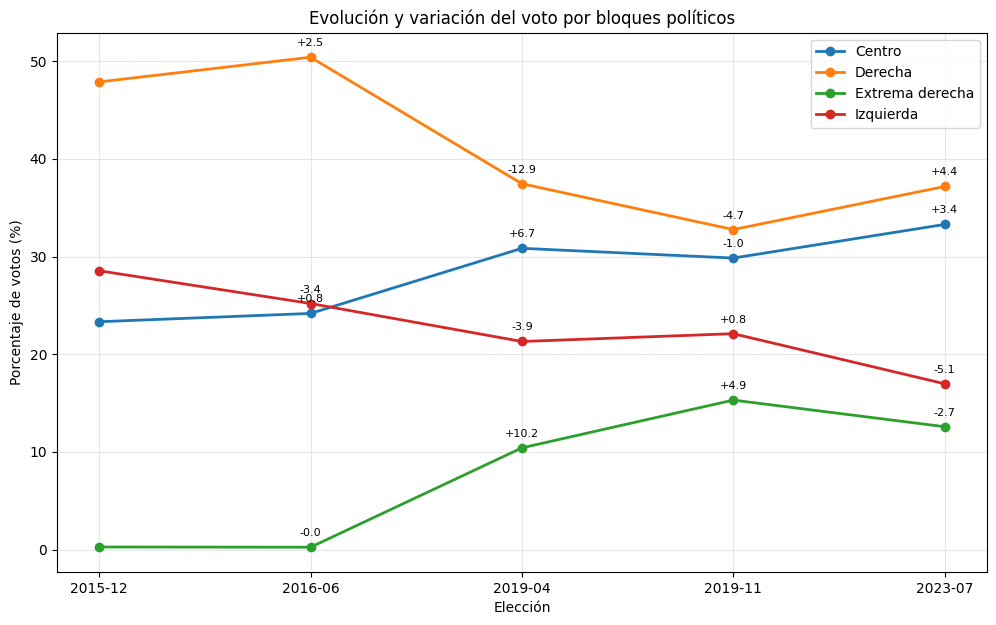

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

bloques = ['Centro', 'Derecha', 'Extrema derecha', 'Izquierda']

for bloque in bloques:

    plt.plot(
        evolucion_bloques['eleccion'],
        evolucion_bloques[f'pct_{bloque}'],
        marker='o',
        linewidth=2,
        label=bloque
    )

    # Variación respecto a la elección anterior
    for i in range(1, len(evolucion_bloques)):

        porcentaje = evolucion_bloques.loc[i, f'pct_{bloque}']
        variacion = evolucion_bloques.loc[i, f'var_{bloque}']

        plt.annotate(
            f'{variacion:+.1f}',
            (evolucion_bloques.loc[i, 'eleccion'], porcentaje),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=8
        )

plt.title('Evolución y variación del voto por bloques políticos')
plt.xlabel('Elección')
plt.ylabel('Porcentaje de votos (%)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
print(desigualdad_limpia.columns.tolist())

['comunidad', 'año', 'Desigualdad (S80/S20)', 'Gini']
